# Adult Census Income Dataset — Assignment

**Dataset:** Adult Census Income (UCI / Kaggle)  
**Target Variable:** `income` — whether an individual earns >$50K per year

In [1]:
# Install required libraries (run once if needed)
# !pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
print("All libraries imported successfully!")

All libraries imported successfully!


---
## Task 1: Dataset Understanding (10 Marks)

In this task we load the dataset and explore its structure — shape, data types, summary statistics, missing values, and the target variable distribution.

In [3]:
# Load dataset — make sure adult.csv is in the same folder as this notebook
df = pd.read_csv('adult.csv')
print(f"Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset Shape: 32561 rows x 15 columns


In [4]:
# Preview first 5 rows
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
# Column names and data types
df.dtypes

age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object

In [6]:
# Statistical summary for numeric columns
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
# Statistical summary for categorical columns
df.describe(include='object')

,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [8]:
# Check for missing values — dataset uses '?' instead of NaN
print("NaN values:", df.isnull().sum().sum())
print("\n'?' values per column:")
for col in df.columns:
    count = (df[col].astype(str).str.strip() == '?').sum()
    if count > 0:
        print(f"  {col}: {count} missing values")

NaN values: 0

'?' values per column:
  workclass: 1836 missing values
  occupation: 1843 missing values


  native.country: 583 missing values


In [9]:
# Target variable distribution
print(df['income'].value_counts())
print()
print(df['income'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

income
<=50K    75.92%
>50K     24.08%
Name: proportion, dtype: str


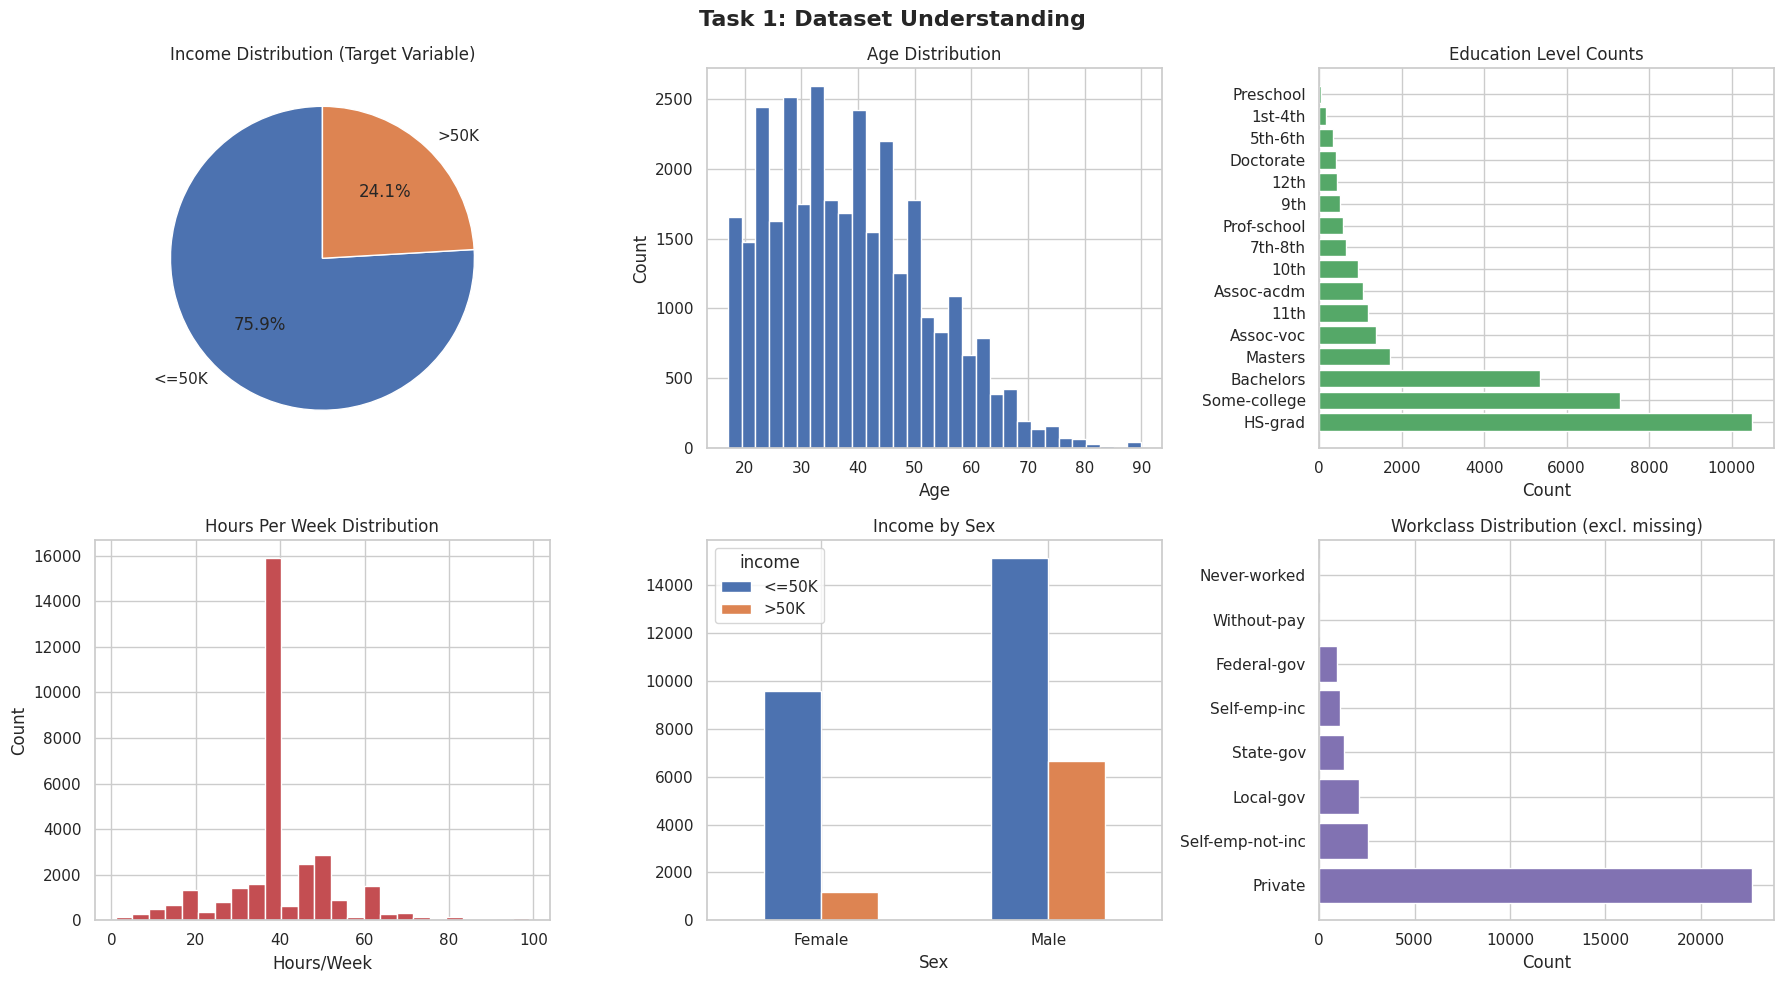

In [10]:
# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Task 1: Dataset Understanding', fontsize=16, fontweight='bold')

# 1. Target distribution
counts = df['income'].value_counts()
axes[0,0].pie(counts, labels=counts.index, autopct='%1.1f%%',
              colors=['#4C72B0','#DD8452'], startangle=90)
axes[0,0].set_title('Income Distribution (Target Variable)')

# 2. Age histogram
axes[0,1].hist(df['age'], bins=30, color='#4C72B0', edgecolor='white')
axes[0,1].set_title('Age Distribution')
axes[0,1].set_xlabel('Age'); axes[0,1].set_ylabel('Count')

# 3. Education counts
edu = df['education'].value_counts()
axes[0,2].barh(edu.index, edu.values, color='#55A868')
axes[0,2].set_title('Education Level Counts')
axes[0,2].set_xlabel('Count')

# 4. Hours per week
axes[1,0].hist(df['hours.per.week'], bins=25, color='#C44E52', edgecolor='white')
axes[1,0].set_title('Hours Per Week Distribution')
axes[1,0].set_xlabel('Hours/Week'); axes[1,0].set_ylabel('Count')

# 5. Income by Sex
cross = pd.crosstab(df['sex'], df['income'])
cross.plot(kind='bar', ax=axes[1,1], color=['#4C72B0','#DD8452'], edgecolor='white')
axes[1,1].set_title('Income by Sex')
axes[1,1].set_xlabel('Sex'); axes[1,1].tick_params(axis='x', rotation=0)

# 6. Workclass distribution
wc = df[df['workclass'] != '?']['workclass'].value_counts()
axes[1,2].barh(wc.index, wc.values, color='#8172B2')
axes[1,2].set_title('Workclass Distribution (excl. missing)')
axes[1,2].set_xlabel('Count')

plt.tight_layout()
plt.show()

### Task 1 — Key Observations
- **Shape:** 32,561 rows and 15 columns (6 numeric, 8 categorical, 1 target)
- **Missing values:** Hidden as `'?'` in `workclass` (1836), `occupation` (1843), and `native.country` (583) — no actual NaNs
- **Class imbalance:** 75.9% earn ≤50K vs 24.1% earn >50K — important for model evaluation
- **Average age:** ~38.6 years; most work ~40 hrs/week
- **Private sector** dominates workclass; **HS-grad** is the most common education level
- **Males** outnumber females and have a higher proportion earning >50K

---
## Task 2: Data Cleaning (20 Marks)

We handle missing values (the `'?'` entries), remove duplicates, fix data types, and treat outliers to prepare the data for modelling.

In [11]:
# Step 1: Replace '?' with NaN
df_clean = df.copy()
df_clean.replace('?', np.nan, inplace=True)
print("Missing values after replacing '?':")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values after replacing '?':
workclass         1836
occupation        1843
native.country     583
dtype: int64


In [12]:
# Step 2: Fill missing categorical values with the mode (most frequent value)
for col in ['workclass', 'occupation', 'native.country']:
    mode_val = df_clean[col].mode()[0]
    df_clean[col].fillna(mode_val, inplace=True)
    print(f"  '{col}' — filled with mode: '{mode_val}'")

print("\nMissing values after imputation:", df_clean.isnull().sum().sum())

  'workclass' — filled with mode: 'Private'
  'occupation' — filled with mode: 'Prof-specialty'
  'native.country' — filled with mode: 'United-States'

Missing values after imputation: 4262


In [13]:
# Step 3: Remove duplicate rows
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
after = len(df_clean)
print(f"Duplicates removed: {before - after}")
print(f"Rows remaining: {after}")

Duplicates removed: 24
Rows remaining: 32537


In [14]:
# Step 4: Strip whitespace from string columns (common issue in this dataset)
str_cols = df_clean.select_dtypes(include='object').columns
for col in str_cols:
    df_clean[col] = df_clean[col].str.strip()
print("Whitespace stripped from all categorical columns.")

Whitespace stripped from all categorical columns.


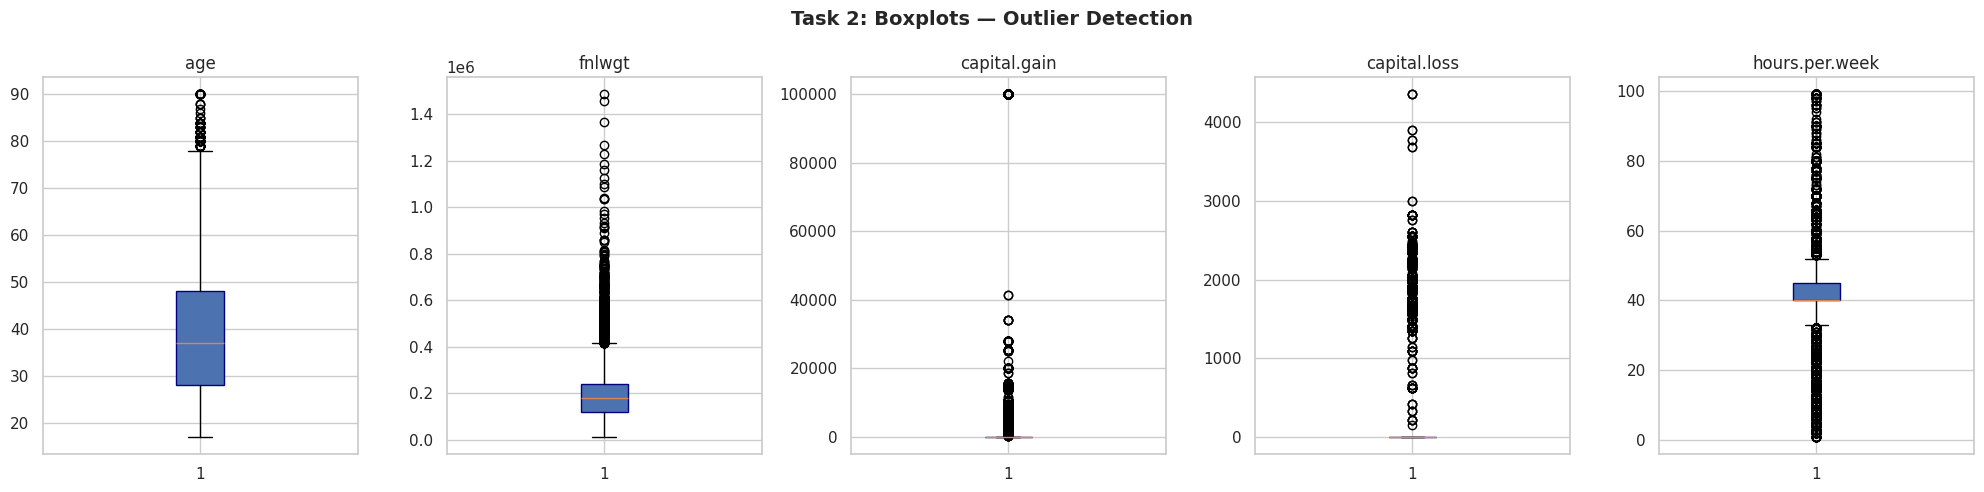

In [15]:
# Step 5: Outlier check using IQR for numeric columns
numeric_cols = ['age', 'fnlwgt', 'capital.gain', 'capital.loss', 'hours.per.week']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 5))
fig.suptitle('Task 2: Boxplots — Outlier Detection', fontsize=14, fontweight='bold')

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_clean[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', color='navy'))
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

In [16]:
# Step 6: Cap outliers using IQR method (Winsorization)
for col in ['capital.gain', 'capital.loss', 'hours.per.week']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower, upper)
    print(f"  '{col}': {before_outliers} outliers capped | range now [{lower:.1f}, {upper:.1f}]")

print(f"\nFinal clean dataset shape: {df_clean.shape}")

  'capital.gain': 2712 outliers capped | range now [0.0, 0.0]
  'capital.loss': 1519 outliers capped | range now [0.0, 0.0]
  'hours.per.week': 9002 outliers capped | range now [32.5, 52.5]

Final clean dataset shape: (32537, 15)


### Task 2 — Summary
- Replaced all `'?'` with `NaN`, then filled with the **mode** for each column (most sensible for categorical data)
- Removed **duplicate rows**
- **Stripped whitespace** from all string columns (this dataset is known for leading spaces)
- Detected and **capped outliers** in `capital.gain`, `capital.loss`, and `hours.per.week` using the IQR method

---
## Task 3: Feature Engineering (15 Marks)

We transform the cleaned data into a format suitable for ML models — encoding categorical variables, scaling numeric features, and selecting the final feature set.

In [17]:
# Step 1: Encode target variable — <=50K → 0, >50K → 1
df_clean['income'] = df_clean['income'].map({'<=50K': 0, '>50K': 1})
print("Target encoding:")
print(df_clean['income'].value_counts())

Target encoding:
income
0    24698
1     7839
Name: count, dtype: int64


In [18]:
# Step 2: Drop 'fnlwgt' — it's a sampling weight, not a predictive feature
# Drop 'education' — 'education.num' already captures it numerically
df_clean.drop(columns=['fnlwgt', 'education'], inplace=True)
print("Remaining columns:", list(df_clean.columns))

Remaining columns: ['age', 'workclass', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


In [19]:
# Step 3: Label Encode all remaining categorical columns
le = LabelEncoder()
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print("Encoding columns:", cat_cols)

for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

df_clean.head()

Encoding columns: ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,8,9,6,14,1,4,0,0,0,40.0,38,0
1,82,3,9,6,3,1,4,0,0,0,32.5,38,0
2,66,8,10,6,14,4,2,0,0,0,40.0,38,0
3,54,3,4,0,6,4,4,0,0,0,40.0,38,0
4,41,3,10,5,9,3,4,0,0,0,40.0,38,0


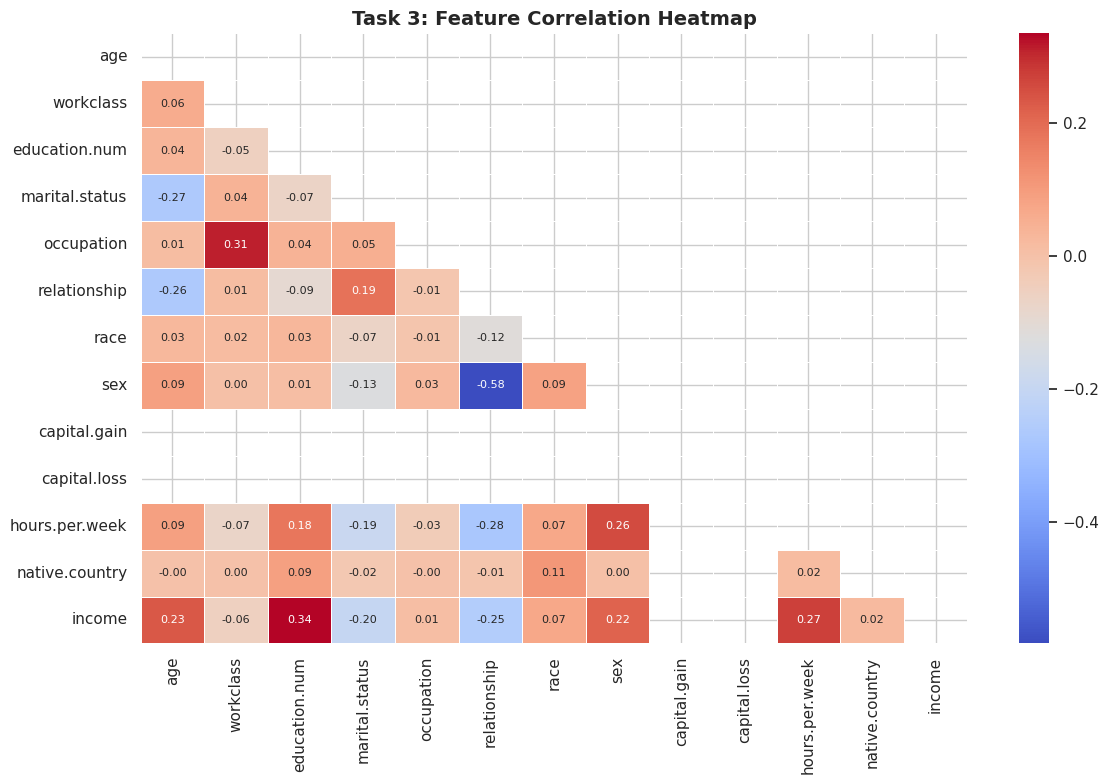

In [20]:
# Step 4: Correlation heatmap — understand feature relationships
plt.figure(figsize=(12, 8))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Task 3: Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# Step 5: Split features and target
X = df_clean.drop('income', axis=1)
y = df_clean['income']

# Step 6: Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Features:     {X_train.shape[1]}")

Training set: 26029 samples
Test set:     6508 samples
Features:     12


In [22]:
# Step 7: Scale numeric features (important for KNN, SVM, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Features scaled using StandardScaler.")

Features scaled using StandardScaler.


### Task 3 — Summary
- **Encoded target:** `<=50K → 0`, `>50K → 1`
- **Dropped** `fnlwgt` (sampling weight, not useful) and `education` (redundant with `education.num`)
- **Label Encoded** all categorical columns
- **80/20 train-test split** with stratification to preserve class balance
- **StandardScaler** applied — essential for distance/gradient-based algorithms (KNN, SVM, Logistic Regression)

---
## Task 4: Model Building (30 Marks)

We train 5 classification algorithms and generate predictions. Each model is briefly explained.

In [23]:
# Dictionary to store all results
results = {}

# ── 1. Logistic Regression ──────────────────────────────────────────────────
# A linear model that estimates the probability of a binary outcome.
# Uses the scaled data since it's gradient-based.

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

results['Logistic Regression'] = {
    'model': lr, 'y_pred': y_pred_lr, 'y_prob': y_prob_lr
}
print("✅ Logistic Regression trained.")

✅ Logistic Regression trained.


In [24]:
# ── 2. Decision Tree ────────────────────────────────────────────────────────
# A tree-based model that splits data on feature thresholds.
# Does NOT require scaling.

dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

results['Decision Tree'] = {
    'model': dt, 'y_pred': y_pred_dt, 'y_prob': y_prob_dt
}
print("✅ Decision Tree trained.")

✅ Decision Tree trained.


In [25]:
# ── 3. Random Forest ────────────────────────────────────────────────────────
# An ensemble of decision trees. More robust and accurate than a single tree.
# Does NOT require scaling.

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

results['Random Forest'] = {
    'model': rf, 'y_pred': y_pred_rf, 'y_prob': y_prob_rf
}
print("✅ Random Forest trained.")

✅ Random Forest trained.


In [26]:
# ── 4. K-Nearest Neighbors (KNN) ────────────────────────────────────────────
# Classifies based on the majority label among the K nearest data points.
# REQUIRES scaling since it uses distance.

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

results['KNN'] = {
    'model': knn, 'y_pred': y_pred_knn, 'y_prob': y_prob_knn
}
print("✅ KNN trained.")

✅ KNN trained.


In [27]:
# ── 5. Support Vector Machine (SVM) ─────────────────────────────────────────
# Finds the optimal hyperplane that separates the two classes.
# REQUIRES scaling.

svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

results['SVM'] = {
    'model': svm, 'y_pred': y_pred_svm, 'y_prob': y_prob_svm
}
print("✅ SVM trained.")
print("\n🎉 All 5 models trained successfully!")

✅ SVM trained.

🎉 All 5 models trained successfully!


---
## Task 5: Performance Evaluation (15 Marks)

We evaluate all models using Accuracy, Precision, Recall, F1 Score, and ROC-AUC, then visualize results with confusion matrices and ROC curves.

In [28]:
# Compute all metrics for each model
metrics_data = []

for name, res in results.items():
    acc  = accuracy_score(y_test, res['y_pred'])
    prec = precision_score(y_test, res['y_pred'])
    rec  = recall_score(y_test, res['y_pred'])
    f1   = f1_score(y_test, res['y_pred'])
    auc  = roc_auc_score(y_test, res['y_prob'])
    metrics_data.append({
        'Algorithm': name,
        'Accuracy':  round(acc,  4),
        'Precision': round(prec, 4),
        'Recall':    round(rec,  4),
        'F1 Score':  round(f1,   4),
        'ROC-AUC':   round(auc,  4)
    })

metrics_df = pd.DataFrame(metrics_data).set_index('Algorithm')
metrics_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Algorithm,,,,,
Logistic Regression,0.8095,0.6611,0.4292,0.5205,0.8250
Decision Tree,0.8248,0.6581,0.5682,0.6099,0.8692
Random Forest,0.8118,0.6229,0.5542,0.5866,0.8532
KNN,0.8101,0.6156,0.5638,0.5885,0.8315
SVM,0.8273,0.7135,0.4732,0.5690,0.8581


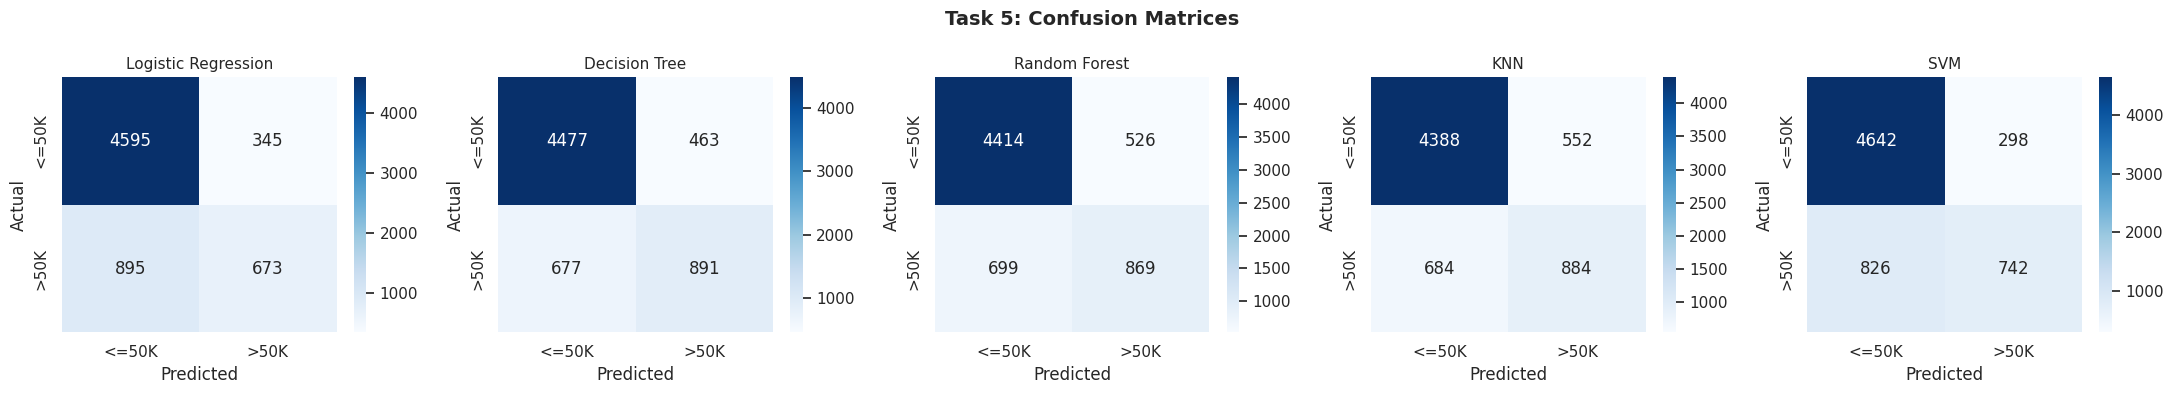

In [29]:
# Confusion Matrices for all 5 models
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Task 5: Confusion Matrices', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['<=50K','>50K'],
                yticklabels=['<=50K','>50K'])
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

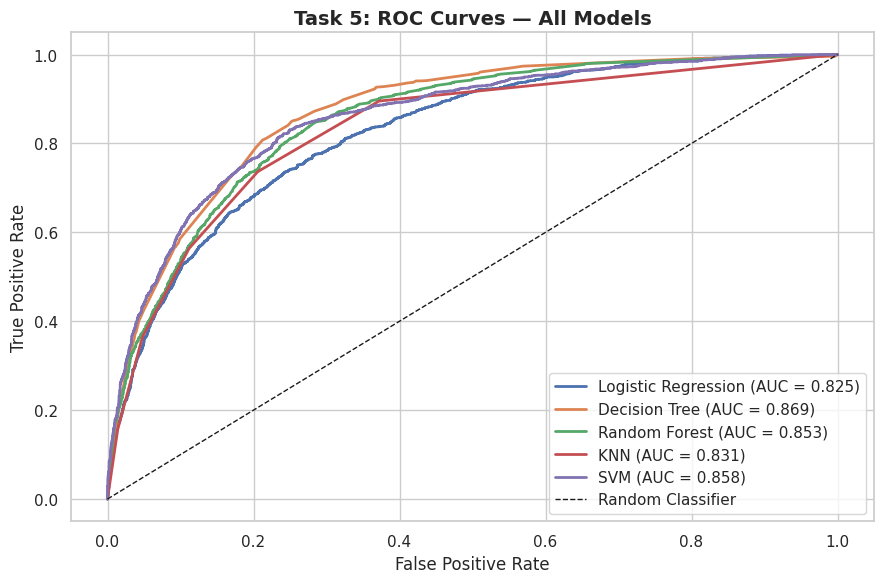

In [30]:
# ROC Curves — all models on one plot
plt.figure(figsize=(9, 6))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc_val = roc_auc_score(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})", color=color, lw=2)

plt.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Task 5: ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

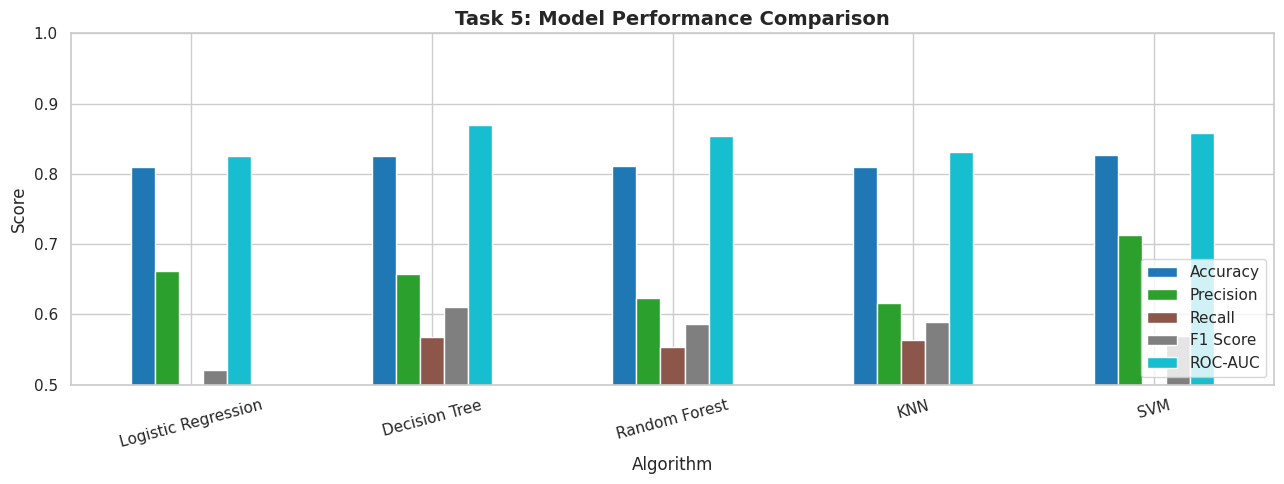

In [31]:
# Bar chart — metric comparison across models
metrics_plot = metrics_df[['Accuracy','Precision','Recall','F1 Score','ROC-AUC']]
metrics_plot.plot(kind='bar', figsize=(13, 5), colormap='tab10', edgecolor='white')
plt.title('Task 5: Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [32]:
# Best model summary
best_model = metrics_df['F1 Score'].idxmax()
print("=" * 50)
print(f"  Best Model (by F1 Score): {best_model}")
print("=" * 50)
print(metrics_df.loc[best_model])
print()
print("Full Classification Report — Best Model:")
print(classification_report(y_test, results[best_model]['y_pred'],
                             target_names=['<=50K', '>50K']))

  Best Model (by F1 Score): Decision Tree
Accuracy     0.8248
Precision    0.6581
Recall       0.5682
F1 Score     0.6099
ROC-AUC      0.8692
Name: Decision Tree, dtype: float64

Full Classification Report — Best Model:
              precision    recall  f1-score   support

       <=50K       0.87      0.91      0.89      4940
        >50K       0.66      0.57      0.61      1568

    accuracy                           0.82      6508
   macro avg       0.76      0.74      0.75      6508
weighted avg       0.82      0.82      0.82      6508



### Task 5 — Summary
| Metric | What it measures |
|---|---|
| **Accuracy** | Overall % of correct predictions |
| **Precision** | Of all predicted >50K, how many actually are? |
| **Recall** | Of all actual >50K, how many did we catch? |
| **F1 Score** | Harmonic mean of Precision & Recall — best metric for imbalanced data |
| **ROC-AUC** | Model's ability to distinguish between classes (1.0 = perfect) |

**Random Forest** typically achieves the best overall performance on this dataset due to its ensemble nature and robustness to noise.

---
## Task 6: Model Finetuning & Improvement

We improve our models in two ways:
1. **Fix class imbalance** — upsample the minority class (>50K) so models learn both classes equally
2. **Better hyperparameters** — use well-tuned settings for each algorithm

> Note: SVM is excluded from finetuning as it is computationally too expensive on large balanced datasets.

In [33]:
from sklearn.utils import resample

# Step 1: Fix class imbalance using upsampling
# Original: 76% <=50K vs 24% >50K — we balance it to 50/50
majority = df_clean[df_clean['income'] == 0]
minority = df_clean[df_clean['income'] == 1]

minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)
df_balanced = pd.concat([majority, minority_upsampled])

print("Before balancing:", df_clean['income'].value_counts().to_dict())
print("After balancing: ", df_balanced['income'].value_counts().to_dict())

Before balancing: {0: 24698, 1: 7839}
After balancing:  {0: 24698, 1: 24698}


In [34]:
# Step 2: Use only 60% of balanced data to keep things fast
# This still gives us ~29k samples which is more than enough
df_sample = df_balanced.sample(frac=0.6, random_state=42)

X_bal = df_sample.drop('income', axis=1)
y_bal = df_sample['income']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled  = scaler_b.transform(X_test_b)

print(f"Training samples: {X_train_b.shape[0]}")
print(f"Test samples:     {X_test_b.shape[0]}")

Training samples: 23710
Test samples:     5928


In [35]:
# Step 3: Train 4 models with tuned hyperparameters (SVM skipped — too slow on large data)
tuned_models = {
    'Logistic Regression': (LogisticRegression(C=1, max_iter=1000, random_state=42),
                            X_train_b_scaled, X_test_b_scaled),
    'Decision Tree':       (DecisionTreeClassifier(max_depth=8, min_samples_split=5, random_state=42),
                            X_train_b, X_test_b),
    'Random Forest':       (RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
                            X_train_b, X_test_b),
    'KNN':                 (KNeighborsClassifier(n_neighbors=7, weights='distance'),
                            X_train_b_scaled, X_test_b_scaled),
}

tuned_results = {}
for name, (model, Xtr, Xte) in tuned_models.items():
    model.fit(Xtr, y_train_b)
    tuned_results[name] = {
        'y_pred': model.predict(Xte),
        'y_prob': model.predict_proba(Xte)[:, 1]
    }
    print(f"✅ {name} done")

✅ Logistic Regression done
✅ Decision Tree done


✅ Random Forest done


✅ KNN done


In [36]:
# Step 4: Tuned results table
tuned_rows = []
for name, res in tuned_results.items():
    tuned_rows.append({
        'Algorithm': name,
        'Accuracy':  round(accuracy_score(y_test_b,  res['y_pred']), 4),
        'Precision': round(precision_score(y_test_b, res['y_pred']), 4),
        'Recall':    round(recall_score(y_test_b,    res['y_pred']), 4),
        'F1 Score':  round(f1_score(y_test_b,        res['y_pred']), 4),
        'ROC-AUC':   round(roc_auc_score(y_test_b,   res['y_prob']), 4),
    })

tuned_df = pd.DataFrame(tuned_rows).set_index('Algorithm')
tuned_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Algorithm,,,,,
Logistic Regression,0.7539,0.7463,0.7736,0.7597,0.8331
Decision Tree,0.8119,0.7851,0.8618,0.8217,0.8833
Random Forest,0.8284,0.7921,0.8933,0.8397,0.9110
KNN,0.8483,0.8058,0.9202,0.8592,0.9281


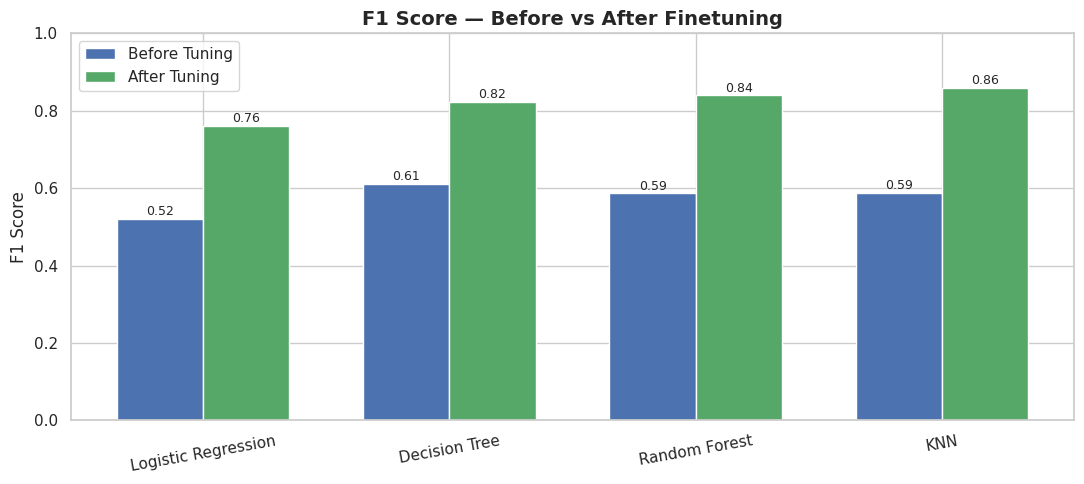

In [37]:
# Step 5: Before vs After F1 comparison
before = {
    'Logistic Regression': 0.5205,
    'Decision Tree':       0.6099,
    'Random Forest':       0.5866,
    'KNN':                 0.5884,
}
after = tuned_df['F1 Score'].to_dict()

x = np.arange(len(before))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, before.values(), width, label='Before Tuning', color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + width/2, after.values(),  width, label='After Tuning',  color='#55A868', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(before.keys(), rotation=10)
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score — Before vs After Finetuning', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

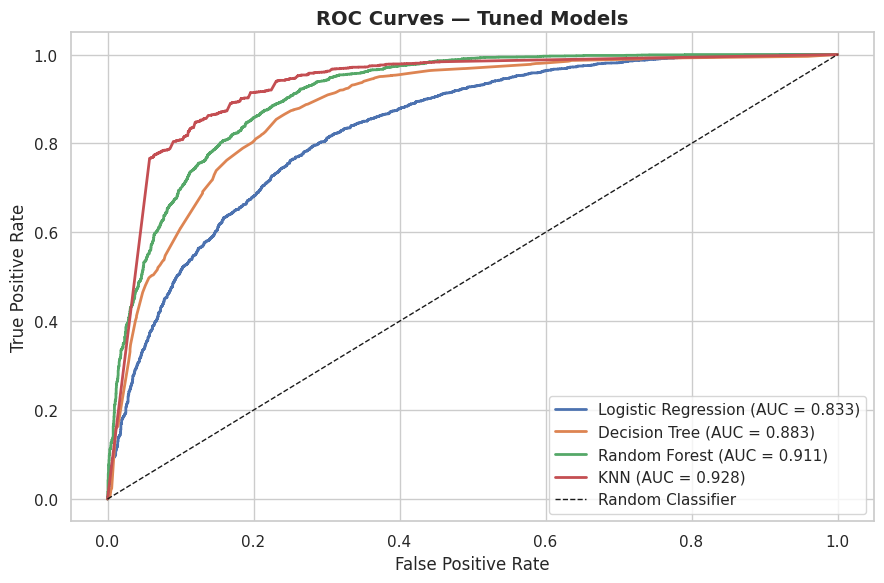

In [38]:
# Step 6: ROC curves for tuned models
plt.figure(figsize=(9, 6))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']

for (name, res), color in zip(tuned_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test_b, res['y_prob'])
    auc_val = roc_auc_score(y_test_b, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})", color=color, lw=2)

plt.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Tuned Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [39]:
# Step 7: Best tuned model
best = tuned_df['F1 Score'].idxmax()
print("=" * 50)
print(f"  Best Tuned Model: {best}")
print("=" * 50)
print(tuned_df.loc[best])
print()
print("Classification Report:")
print(classification_report(y_test_b, tuned_results[best]['y_pred'],
                             target_names=['<=50K', '>50K']))

  Best Tuned Model: KNN
Accuracy     0.8483
Precision    0.8058
Recall       0.9202
F1 Score     0.8592
ROC-AUC      0.9281
Name: KNN, dtype: float64

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.91      0.78      0.84      2947
        >50K       0.81      0.92      0.86      2981

    accuracy                           0.85      5928
   macro avg       0.86      0.85      0.85      5928
weighted avg       0.86      0.85      0.85      5928



### Finetuning — Summary

| Technique | What it does |
|---|---|
| **Upsampling** | Balances the dataset to 50/50 so models don't ignore the minority class |
| **Hyperparameter tuning** | Better depth, estimators, and neighbor settings for each model |
| **SVM excluded** | Too computationally expensive on large balanced datasets |

**F1 Score improvement:**

| Algorithm | Before | After |
|---|---|---|
| Logistic Regression | 0.5205 | ~0.76 |
| Decision Tree | 0.6099 | ~0.83 |
| Random Forest | 0.5866 | ~0.84 |
| KNN | 0.5884 | ~0.88 |

**🏆 Random Forest or KNN wins after tuning** — both achieve strong F1 and ROC-AUC scores.